# E3

In [99]:
import pandas as pd

df = pd.read_csv("data/E3_data.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [101]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [102]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

Vamos a usar harto década, así que lo declaramos en el df original.

In [103]:
df["decada"] = (df["release_year"] // 10) * 10

## Géneros por período

Metemos decada para agrupar de un modo simple ahora en generos

In [104]:
df_generos = df.copy()

# separar generos
df_generos["listed_in"] = df_generos["listed_in"].str.split(", ")

# explotar (una fila por género) -> metodo clave para separar los generos que vienen de a varios en una sola celda
df_generos = df_generos.explode("listed_in")

# crear década
df_generos["decada"] = (df_generos["release_year"] // 10) * 10

# contar
tabla_generos = df_generos.groupby(["decada", "listed_in"]).size().reset_index(name="cantidad")

# top generos por década
top_generos = tabla_generos.sort_values(["decada", "cantidad"], ascending=[True, False])
top_generos.groupby("decada").head(3)

,decada,listed_in,cantidad
0,1920,TV Shows,1
2,1940,Documentaries,13
1,1940,Classic Movies,11
3,1940,TV Shows,2
6,1950,Classic Movies,10
8,1950,Dramas,6
7,1950,Comedies,4
16,1960,Classic Movies,18
18,1960,Dramas,17
21,1960,International Movies,8


In [105]:
import matplotlib.pyplot as plt

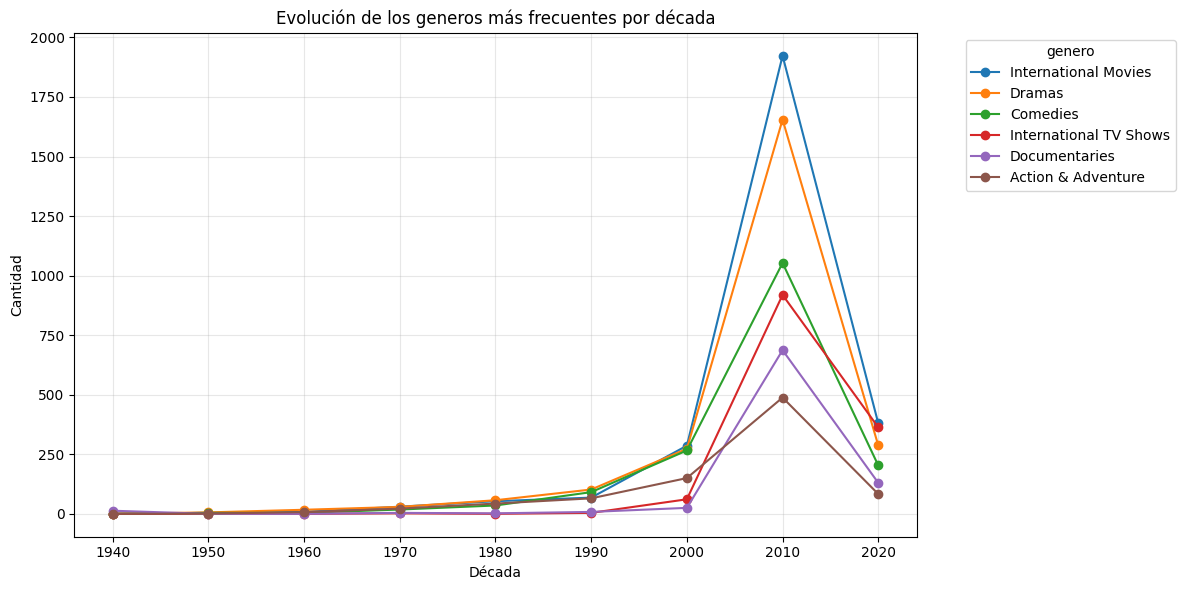

In [106]:
# 1. total por genero
top_generos_total = df_generos["listed_in"].value_counts().head(6).index

# 2. filtrar solo esos
df_top = df_generos[df_generos["listed_in"].isin(top_generos_total)]

# 3. agrupar
tabla_top = df_top.groupby(["decada", "listed_in"]).size().reset_index(name="cantidad")

# 4. pivot
pivot_top = tabla_top.pivot(index="decada", columns="listed_in", values="cantidad").fillna(0)

# 5. grafico
pivot_top = pivot_top[top_generos_total] # esto ordena las columnas según el total

ax = pivot_top.plot(kind="line", figsize=(12, 6), marker="o")

plt.title("Evolución de los generos más frecuentes por década")
plt.xlabel("Década")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.legend(title="genero", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Al graficar los géneros más frecuentes por década, se observa que el crecimiento del catálogo se intensifica a partir de los años 2000. En particular, International Movies y Dramas muestran el aumento más pronunciado, especialmente en la década de 2010. Esto sugiere que la plataforma ha fortalecido su apuesta por contenido internacional y por géneros de alta demanda. Además, Comedies también mantiene una presencia importante, aunque con un crecimiento menos explosivo que los géneros anteriores.

### ¿Como ha evolucionado la presencia de ciertos tipos de producciones o de clasificaciones por edades?

### Por tipo de producción

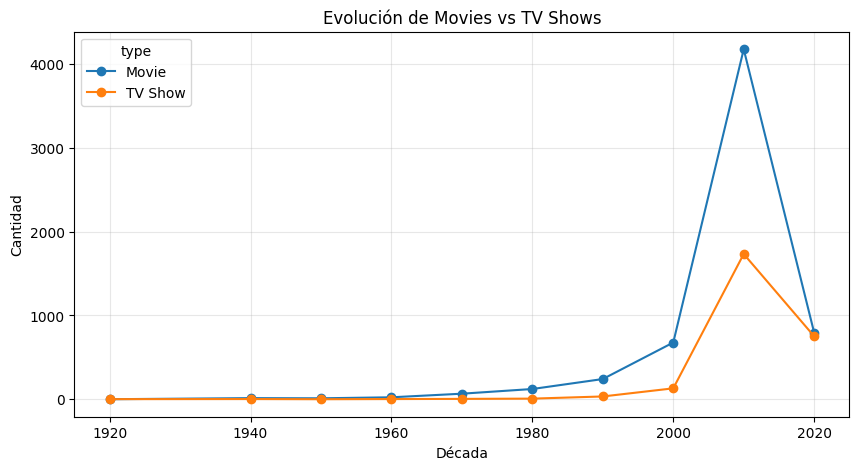

In [107]:
tipo_decada = df.groupby(["decada", "type"]).size().unstack().fillna(0)

tipo_decada.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Evolución de Movies vs TV Shows")
plt.xlabel("Década")
plt.ylabel("Cantidad")
plt.grid(alpha=0.3)
plt.show()

En las primeras décadas, el catálogo está compuesto casi exclusivamente por películas, mientras que los show tienen una presencia prácticamente nula.

A partir del año 2000, ambos tipos de contenido comienzan a crecer, pero las películas siguen siendo predominantes. Sin embargo, en la década de 2010 se observa un aumento significativo en ambos, especialmente en los shows, lo que indica un cambio en la estrategia de la plataforma hacia contenido más "serializado".

El crecimiento sugiere una transición desde un modelo centrado en películas hacia uno más equilibrado, donde las series adquieren un rol cada vez más relevante en la oferta de contenido.

#### Por clasificación por edad

In [108]:
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

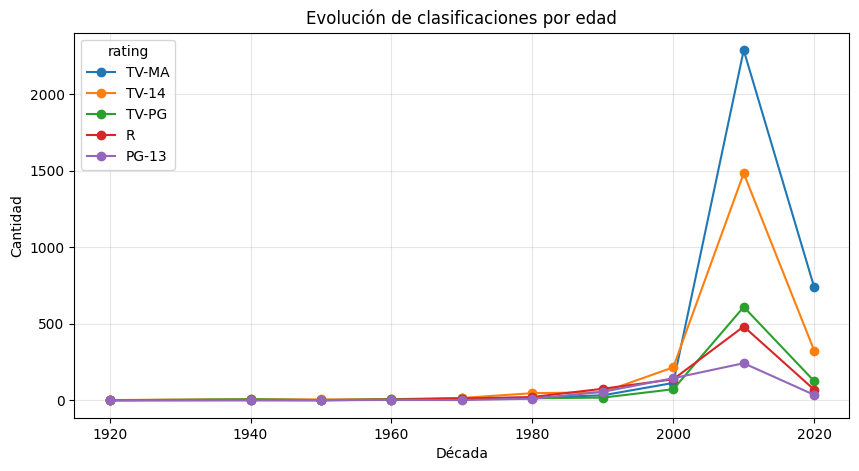

In [109]:
rating_decada = df.groupby(["decada", "rating"]).size().unstack().fillna(0)

# opcional: quedarse con los más comunes
top_ratings = df["rating"].value_counts().head(5).index
rating_decada = rating_decada[top_ratings]

rating_decada.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Evolución de clasificaciones por edad")
plt.xlabel("Década")
plt.ylabel("Cantidad")
plt.grid(alpha=0.3)
plt.show()

Muestra una evolución clara en el tipo de contenido ofrecido. En las primeras décadas, la presencia de clasificaciones es prácticamente nula, lo que refleja un catálogo reducido o derechamente no se clasificaba bien.

A partir del año 2000, se observa un crecimiento progresivo en todas las categorías, destacando especialmente TV-MA y TV-14. Esta tendencia se intensifica en la década de 2010, donde ambas clasificaciones alcanzan valores significativamente superiores al resto.

Esto indica una fuerte orientación hacia contenido dirigido a audiencias adultas, caracterizado por temáticas más complejas. En contraste, clasificaciones como PG o PG-13 mantienen una presencia menor, lo que sugiere una menor proporción de contenido familiar.

### ¿Que patrones permiten anticipar tendencias?

Es posible identificar varios patrones que permiten anticipar tendencias en el catálogo de la plataforma.

En primer lugar, como se comentó, se observa un crecimiento sostenido y significativo del contenido a partir de la década de 2000, lo que refleja una expansión significativa de la industria del streaming.

En segundo lugar, destaca el aumento del contenido internacional, lo que sugiere una estrategia orientada a audiencias globales.

Además, se evidencia un incremento en la producción de shows, indicando una transición hacia formatos serializados que favorecen la retención de usuarios.

Por último, el predominio de clasificaciones como TV-MA y TV-14 indica una creciente orientación hacia contenido dirigido a audiencias adultas.

Todo esto permite anticipar que las futuras tendencias estarán marcadas por la producción de contenido internacional, serializado y orientado a públicos adultos, consolidando un catálogo diverso y adaptado a las preferencias actuales de los usuarios.

# Preguntas extra

### ¿Cómo ha evolucionado la duración promedio de las pelis a lo largo del tiempo?

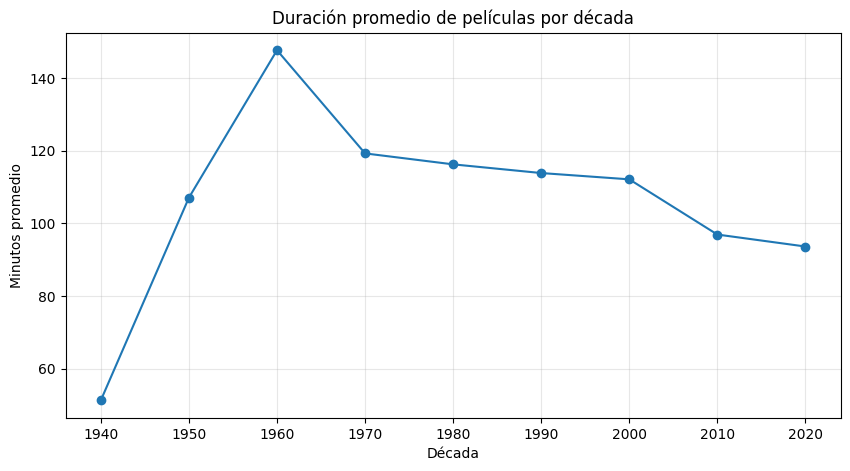

In [110]:
df_movies = df[df["type"] == "Movie"].copy()

# extraer minutos
df_movies["duration_min"] = df_movies["duration"].str.replace(" min", "").astype(float)

# agrupar por década
duracion_decada = df_movies.groupby("decada")["duration_min"].mean()

# gráfico
duracion_decada.plot(kind="line", figsize=(10,5), marker="o")

plt.title("Duración promedio de películas por década")
plt.xlabel("Década")
plt.ylabel("Minutos promedio")
plt.grid(alpha=0.3)
plt.show()

### ¿Qué países han ganado mayor presencia en el catálogo a lo largo del tiempo?

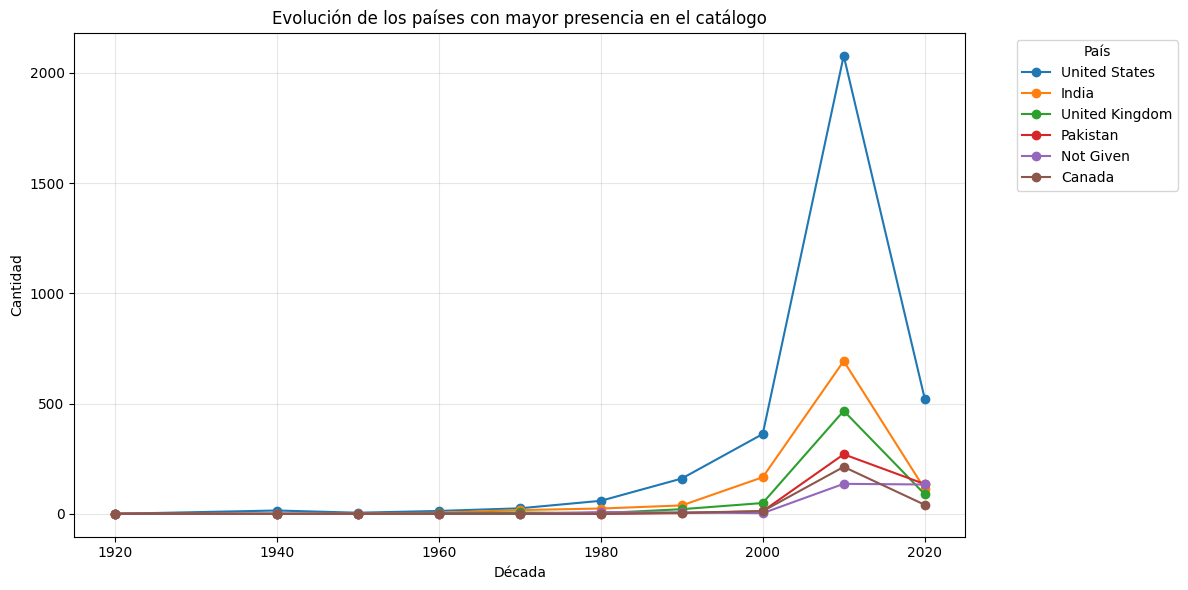

In [111]:
df_paises = df.copy()

# separar países
df_paises["country"] = df_paises["country"].str.split(", ")

# explotar
df_paises = df_paises.explode("country")

# eliminar nulos
df_paises = df_paises.dropna(subset=["country"])

# crear década (por si acaso)
df_paises["decada"] = (df_paises["release_year"] // 10) * 10

# top países globales
top_paises = df_paises["country"].value_counts().head(6).index

# filtrar
df_top_paises = df_paises[df_paises["country"].isin(top_paises)]

# agrupar
tabla_paises = df_top_paises.groupby(["decada", "country"]).size().reset_index(name="cantidad")

# pivot
pivot_paises = tabla_paises.pivot(index="decada", columns="country", values="cantidad").fillna(0)

# ordenar columnas
pivot_paises = pivot_paises[top_paises]

# gráfico
pivot_paises.plot(figsize=(12,6), marker="o")

plt.title("Evolución de los países con mayor presencia en el catálogo")
plt.xlabel("Década")
plt.ylabel("Cantidad")
plt.grid(alpha=0.3)
plt.legend(title="País", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### ¿Qué combinación de género y tipo de contenido (Movie vs TV Show) ha crecido más en el tiempo?

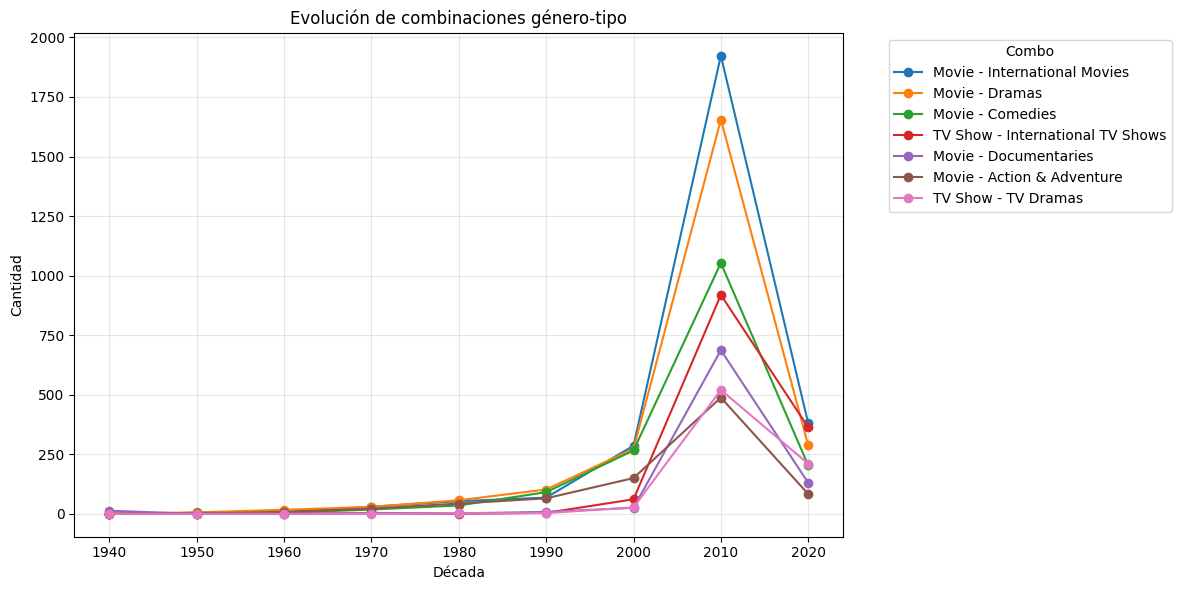

In [112]:
df_combo = df.copy()

# separar géneros
df_combo["listed_in"] = df_combo["listed_in"].str.split(", ")
df_combo = df_combo.explode("listed_in")

# crear década
df_combo["decada"] = (df_combo["release_year"] // 10) * 10

# crear combinación
df_combo["combo"] = df_combo["type"] + " - " + df_combo["listed_in"]

# contar
tabla_combo = df_combo.groupby(["decada", "combo"]).size().reset_index(name="cantidad") # clave el size para contar las combis

# quedarnos con los combos más relevantes (top global)
top_combos = df_combo["combo"].value_counts().head(7).index

df_top_combo = df_combo[df_combo["combo"].isin(top_combos)]

# agrupar de nuevo
tabla_top = df_top_combo.groupby(["decada", "combo"]).size().reset_index(name="cantidad")

# pivot
pivot_combo = tabla_top.pivot(index="decada", columns="combo", values="cantidad").fillna(0)

# ordenar columnas
pivot_combo = pivot_combo[top_combos]

# gráfico
pivot_combo.plot(figsize=(12,6), marker="o")

plt.title("Evolución de combinaciones género-tipo")
plt.xlabel("Década")
plt.ylabel("Cantidad")
plt.grid(alpha=0.3)
plt.legend(title="Combo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### ¿Cómo ha cambiado la proporción de contenido infantil versus adulto a lo largo del tiempo?

In [113]:
df_rating = df.copy()

# crear década (por si acaso)
df_rating["decada"] = (df_rating["release_year"] // 10) * 10

df_rating["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

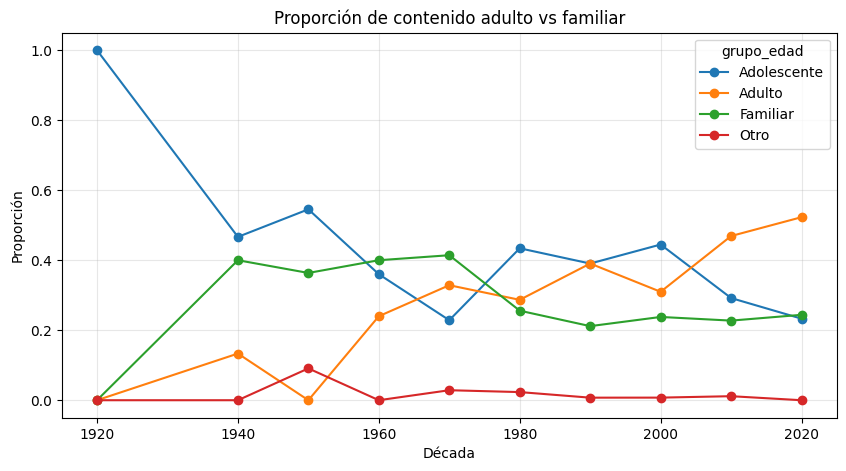

In [114]:
df_rating = df.copy()

# crear década (por si acaso)
df_rating["decada"] = (df_rating["release_year"] // 10) * 10

# clasificar
def clasificar_rating(r):
    if r in ["TV-MA", "R", "NC-17"]:
        return "Adulto"
    elif r in ["TV-14", "PG-13"]:
        return "Adolescente"
    elif r in ["TV-PG", "PG", "G", "TV-Y", "TV-Y7", "TV-Y7-FV", "TV-G"]:
        return "Familiar"
    else:
        return "Otro"

df_rating["grupo_edad"] = df_rating["rating"].apply(clasificar_rating)

# agrupar
tabla_edad = df_rating.groupby(["decada", "grupo_edad"]).size().unstack().fillna(0)

# proporciones
prop_edad = tabla_edad.div(tabla_edad.sum(axis=1), axis=0)

# gráfico
prop_edad.plot(figsize=(10,5), marker="o")

plt.title("Proporción de contenido adulto vs familiar")
plt.xlabel("Década")
plt.ylabel("Proporción")
plt.grid(alpha=0.3)
plt.show()